In [1]:
MODEL_CLS = "dvae"
NOISE = "01"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{MODEL_CLS}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_ML


In [4]:
import sys
sys.path.append("src")

# Packages

In [5]:
import pandas as pd
from anomaly.stochastic import config, pipeline, trainer, evaluator, utils
import autoencoder

In [ ]:
cfg = config.builder.config_builder(PATH_CONFIG_FILE)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/creditcard.csv"
origin = pd.read_csv(PATH)

In [9]:
DROP_COL = ["Time", "Amount"]
df = origin.drop(columns=DROP_COL)

In [10]:
Y_COL = "Class"

kwargs = dict(
    df=df,
    y_col=Y_COL,
    cfg=cfg.pipeline,
)

dataloaders = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    noise=float(NOISE)*1e-1,
    **cfg.model.params,
)

model = autoencoder.dvae.DenoisedVariationalAutoEncoder(**kwargs)

# Train

In [12]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [13]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.1328
	BEST EPOCH: 15


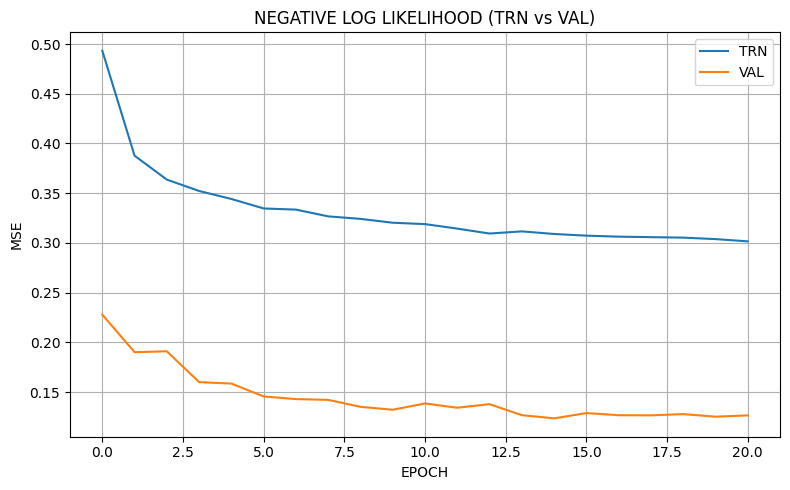

In [14]:
kwargs = dict(
    objs=(records["trn"]["nll"], records["val"]["nll"]),
    labels=("TRN", "VAL"),
    xlabel="EPOCH",
    ylabel="MSE",
    title="NEGATIVE LOG LIKELIHOOD (TRN vs VAL)",
    figsize=(8,5),
)

utils.visualizer.main(**kwargs)

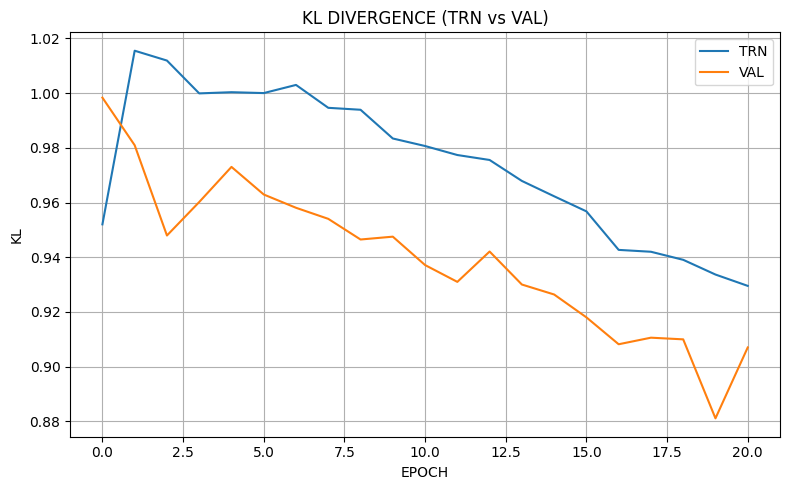

In [15]:
kwargs = dict(
    objs=(records["trn"]["kl"], records["val"]["kl"]),
    labels=("TRN", "VAL"),
    xlabel="EPOCH",
    ylabel="KL",
    title="KL DIVERGENCE (TRN vs VAL)",
    figsize=(8,5),
)

utils.visualizer.main(**kwargs)

# Evaluation

In [16]:
kwargs = dict(
    model=model,
    scores=records["anomaly"],
    cfg=cfg.evaluator,
)

eval = evaluator.builder.evaluator_builder(**kwargs)

In [17]:
result, metrics_sheet = eval(dataloaders["tst"])

TST: 100%|██████████| 8/8 [00:00<00:00, 327.09it/s]


In [18]:
metrics_sheet

,p,threshold,tp,tn,fp,fn,accuracy,precision,recall,f1
0,0.950,0.282593,429,474,18,63,0.917683,0.959732,0.871951,0.913738
1,0.955,0.302530,428,476,16,64,0.918699,0.963964,0.869919,0.914530
2,0.960,0.327667,422,478,14,70,0.914634,0.967890,0.857724,0.909483
3,0.965,0.362651,418,478,14,74,0.910569,0.967593,0.849594,0.904762
4,0.970,0.408255,416,481,11,76,0.911585,0.974239,0.845528,0.905332
5,0.975,0.469558,413,484,8,79,0.911585,0.980998,0.839431,0.904710
6,0.980,0.557417,413,487,5,79,0.914634,0.988038,0.839431,0.907692
7,0.985,0.722744,408,490,2,84,0.912602,0.995122,0.829268,0.904656
8,0.990,1.034683,406,491,1,86,0.911585,0.997543,0.825203,0.903226
9,0.995,1.844928,391,491,1,101,0.896341,0.997449,0.794715,0.884615


# Save

In [ ]:
PATH = f'./result/score/{cfg.model_cls}_{NOISE}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
result.to_csv(**kwargs)

In [ ]:
PATH = f'./result/metric/{cfg.model_cls}_{NOISE}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
metrics_sheet.to_csv(**kwargs)

In [20]:
PATH = f'./checkpoints/{cfg.model_cls}_{NOISE}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)